# Agitation prediction: Data cleaning

**Author:** Eva Rombouts  
**Date:** 2024-07-19  
**Version:** 1.0

### Description
This script performs data cleaning on a dataset of nursing home notes. 
The cleaned dataset retains two columns: text and label. The label column is 1 if the topic is 'onrust' (agitation) and 0 otherwise.

In [1]:
import os

def check_environment():
    try:
        import google.colab
        return "Google Colab"
    except ImportError:
        return "Local Environment"

env = check_environment()
if env == "Google Colab":
    print("Running in Google Colab")
    !pip install -q datasets
    from google.colab import drive, userdata
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/GenCareAI/scripts/200_agitation_models')
    HF_TOKEN = userdata.get('HF_TOKEN')
else:
    print("Running in Local Environment")
    # !pip install -q matplotlib
    from dotenv import load_dotenv
    load_dotenv()
    HF_TOKEN = os.getenv('HF_TOKEN')

Running in Local Environment


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

/Users/eva/anaconda3/envs/gcai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the dataset from Hugging Face
PATH_HF_DATASET = 'ekrombouts/dutch_nursing_home_notes'
dataset = load_dataset(PATH_HF_DATASET, token=HF_TOKEN)
df = dataset['train'].to_pandas()

WORD_COUNT_MAX = 61

SAMPLE_SIZE = 10000
SEED = 6

In [4]:
# Explore a sample of the data
print(df.sample(5))
print('\n'+ 10*'*'+ '\n')
df.info()

                                                    note         topic
41468  Mw heeft toenemende moeite met het slikken van...     symptomen
6698   Diarree gemeld door mevrouw na de lunch. Geen ...     symptomen
43069  Mw vanochtend haar valalarm vergeten om te doe...    mobiliteit
13567  Mw. stond midden in de nacht plotseling naast ...       nachten
18583  Dhr wilde vanochtend enkel wat yoghurt en sloe...  eten_drinken

**********

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43283 entries, 0 to 43282
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   note    43274 non-null  object
 1   topic   43283 non-null  object
dtypes: object(2)
memory usage: 676.4+ KB


In [5]:
# There are just a couple of missing values. We'll remove these later
df[df.isna().any(axis=1)]

,note,topic
18569,None,eten_drinken
19594,None,sociaal
20249,None,huid
21273,None,medisch_logistiek
22138,None,nachten
23104,None,onrust
24075,None,symptomen
25039,None,mobiliteit
26051,None,ADL


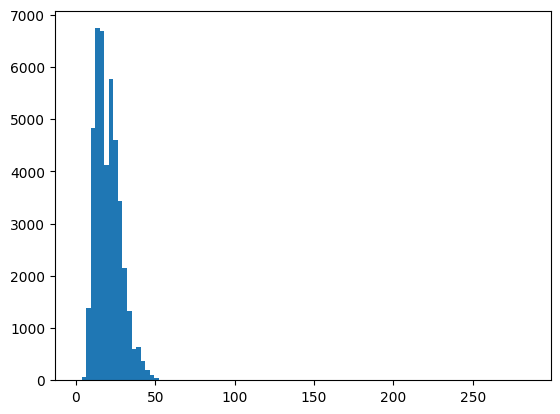

Number of rows with note_word_count > 61: 166
**********
Verband om wond linkerhand mevrouw vervangen, wond lijkt goed te genezen.
- Vergeten medicatie van mevrouw verpleegkundige gesignaleerd, medicijnen alsnog toegediend.
- Familie van bewoner heeft interesse getoond in deelname aan eerstvolgende familiegesprek betreffende zorgplan.
- Mevrouw heeft geklaagd over pijn in onderrug, fysiotherapeut heeft ingepland voor behandeling morgenochtend.
- Zoon van meneer verzoekt om afschrift van medisch dossier voor externe consultatie.
- Observatie van verwardheid bij bewoner tijdens ochtendzorg, team ingelicht voor extra monitoring.
- Dieetwensen van heer besproken, voortaan vegetarische opties toevoegen aan maaltijden.
- Telefoongesprek met dochter van cliënt: aangegeven dat bezoek van oude bekende is goedgekeurd en ingepland voor morgenmiddag.
- In artsenvisite benoemd: vragenlijst voor neurologisch onderzoek opgesteld en verzoek ingediend voor consult met neuroloog.
- Medicatie van mevrouw

[None, None, None, None]

In [6]:
# Exploring large notes yields that these have been incorrectly parsed, so drop
df['note_word_count'] = df['note'].str.split().str.len()

plt.hist(df['note_word_count'], bins=100)
plt.show()
_ = df[df['note_word_count'] > WORD_COUNT_MAX]
print(f"Number of rows with note_word_count > {WORD_COUNT_MAX}: {len(_)}")
[print(10*'*' + '\n' + note) for note in _['note'].sample(4)]

In [7]:
# Clean the dataframe by removing missing values and large notes
df_agitation = (
    df.dropna()
      .drop(df[df['note_word_count'] > WORD_COUNT_MAX].index)
      .assign(label=(df['topic'] == 'onrust').astype(int))
      .rename(columns={'note': 'text'})
      [['text', 'label']]
)

In [8]:
print(df_agitation.sample(5))
print(df_agitation['label'].value_counts())
df_agitation.info()

                                                    text  label
21948  Dhr. V. had vanochtend last van constipatie. E...      0
39972  De nacht verliep rustig zonder enige vorm van ...      0
12891  Mevr. moeilijk te wekken vanochtend. Bloeddruk...      0
20798  Op de rug van mw. zijn rode plekken waargenome...      0
18197  Na incontinentie episode is dhr. verschoond en...      0
label
0    38109
1     4999
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 43108 entries, 0 to 43282
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    43108 non-null  object
 1   label   43108 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1010.3+ KB


In [10]:
df_agitation.to_csv('../../data/agitation.csv', index=False)